<a href="https://colab.research.google.com/github/pedromoreira427/Farmtech-solutions-PBL5/blob/main/pedrogustavofrancamoreira_rm568262_pbl_fase5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FarmTech Solutions — Previsão de Rendimento de Safra
**Fase 5 | FIAP | PBL**

---

## Introdução

Este notebook apresenta a solução de Machine Learning desenvolvida para a **FarmTech Solutions**, empresa que presta serviços de IA para uma fazenda de médio porte de 200 hectares.

O objetivo é, a partir de dados climáticos e de solo (precipitação, umidade e temperatura), **prever o rendimento das culturas** (em toneladas por hectare) utilizando modelos de regressão supervisionada, além de explorar tendências e padrões via clusterização.

### Dataset
O arquivo `crop_yield.csv` contém registros de 4 culturas com as seguintes variáveis:
- **Crop**: tipo de cultura
- **Precipitation (mm day-1)**: precipitação em mm por dia
- **Specific Humidity at 2 Meters (g/kg)**: umidade específica a 2m
- **Relative Humidity at 2 Meters (%)**: umidade relativa a 2m
- **Temperature at 2 Meters (C)**: temperatura a 2m
- **Yield**: rendimento (toneladas/hectare) — variável alvo

---

## 1. Importação de Bibliotecas

In [1]:
# Manipulação e análise de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Pré-processamento
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score

# Modelos de Regressão
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

# Métricas
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Clusterização
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Utilitários
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


---
## 2. Análise Exploratória dos Dados (EDA)

Nesta etapa, vamos carregar e explorar o dataset para entender sua estrutura, distribuições, possíveis valores ausentes e correlações entre variáveis.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

caminho = '/content/drive/MyDrive/Colab Notebooks/crop_yield.csv'

df = pd.read_csv(caminho)

print(f'Shape do dataset: {df.shape}')
print(f'Colunas: {list(df.columns)}')
df.head(10)

Mounted at /content/drive
Shape do dataset: (156, 6)
Colunas: ['Crop', 'Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)', 'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)', 'Yield']


,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800
5,"Cocoa, beans",2339.30,17.70,84.54,25.76,8850
6,"Cocoa, beans",2326.09,18.09,84.63,26.11,9003
7,"Cocoa, beans",2718.08,18.30,85.43,26.12,9880
8,"Cocoa, beans",2061.61,17.80,84.36,25.88,9201
9,"Cocoa, beans",1934.62,17.94,83.43,26.21,8300


In [3]:
# Informações gerais do dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    object 
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.4+ KB


In [5]:
# Estatísticas descritivas
df.describe().round(2)

,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,156.00,156.00,156.00,156.00,156.00
mean,2486.50,18.20,84.74,26.18,56153.10
std,289.46,0.29,1.00,0.26,70421.96
min,1934.62,17.54,82.11,25.56,5249.00
25%,2302.99,18.03,84.12,26.02,8327.75
50%,2424.55,18.27,84.85,26.13,18871.00
75%,2718.08,18.40,85.51,26.30,67518.75
max,3085.79,18.70,86.10,26.81,203399.00


In [4]:
# Verificação de valores nulos
print('Valores nulos por coluna:')
print(df.isnull().sum())
print(f'\nTotal de registros: {len(df)}')
print(f'Culturas únicas: {df["Crop"].nunique()}')
print(f'\nDistribuição por cultura:')
print(df['Crop'].value_counts())

Valores nulos por coluna:
Crop                                    0
Precipitation (mm day-1)                0
Specific Humidity at 2 Meters (g/kg)    0
Relative Humidity at 2 Meters (%)       0
Temperature at 2 Meters (C)             0
Yield                                   0
dtype: int64

Total de registros: 156
Culturas únicas: 4

Distribuição por cultura:
Crop
Cocoa, beans       39
Oil palm fruit     39
Rice, paddy        39
Rubber, natural    39
Name: count, dtype: int64


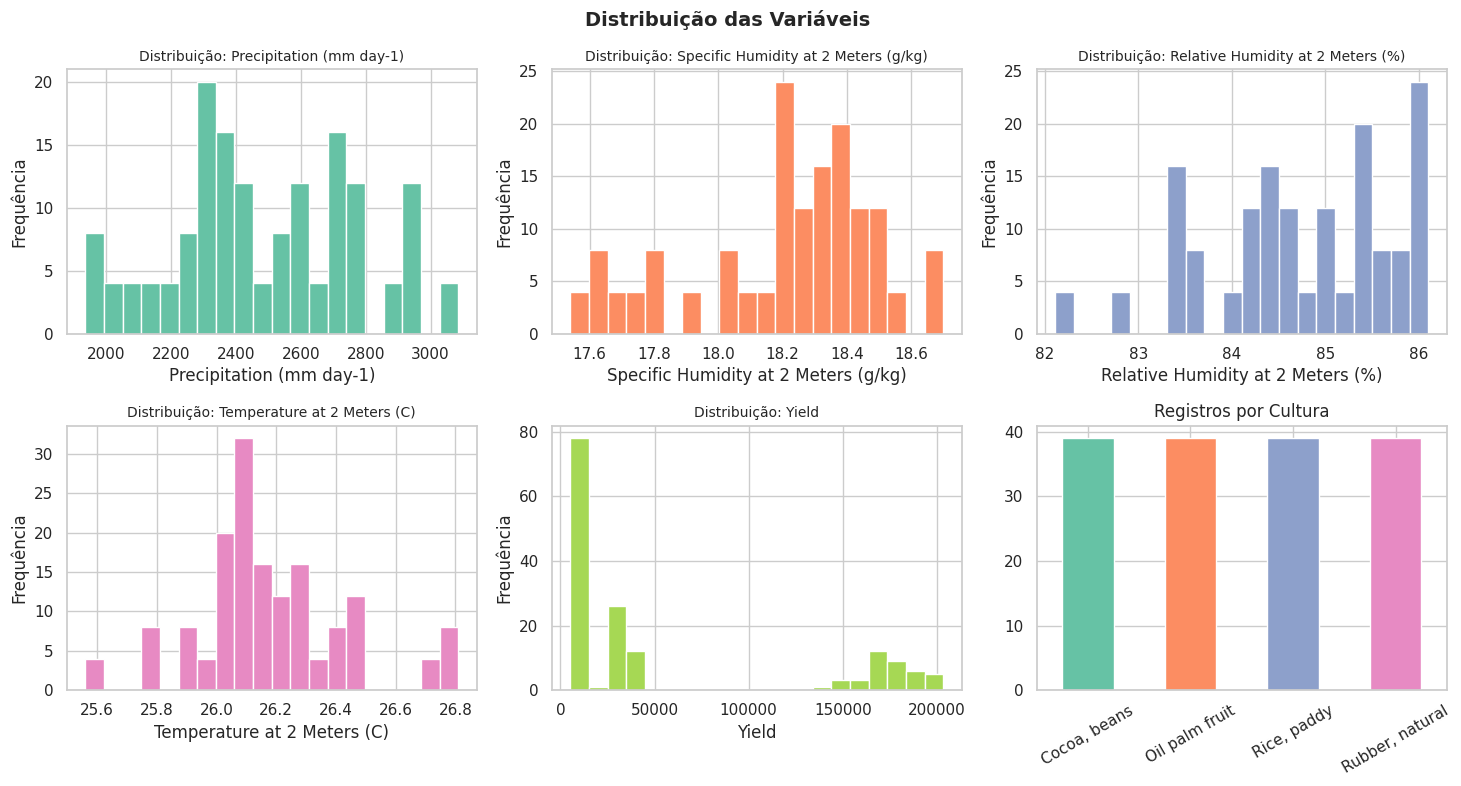

In [5]:
# Distribuição das variáveis numéricas
num_cols = ['Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)',
            'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)', 'Yield']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=20, edgecolor='white', color=sns.color_palette('Set2')[i])
    axes[i].set_title(f'Distribuição: {col}', fontsize=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequência')

# Distribuição por cultura no último subplot
df['Crop'].value_counts().plot(kind='bar', ax=axes[5], color=sns.color_palette('Set2'))
axes[5].set_title('Registros por Cultura')
axes[5].set_xlabel('')
axes[5].tick_params(axis='x', rotation=30)

plt.suptitle('Distribuição das Variáveis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

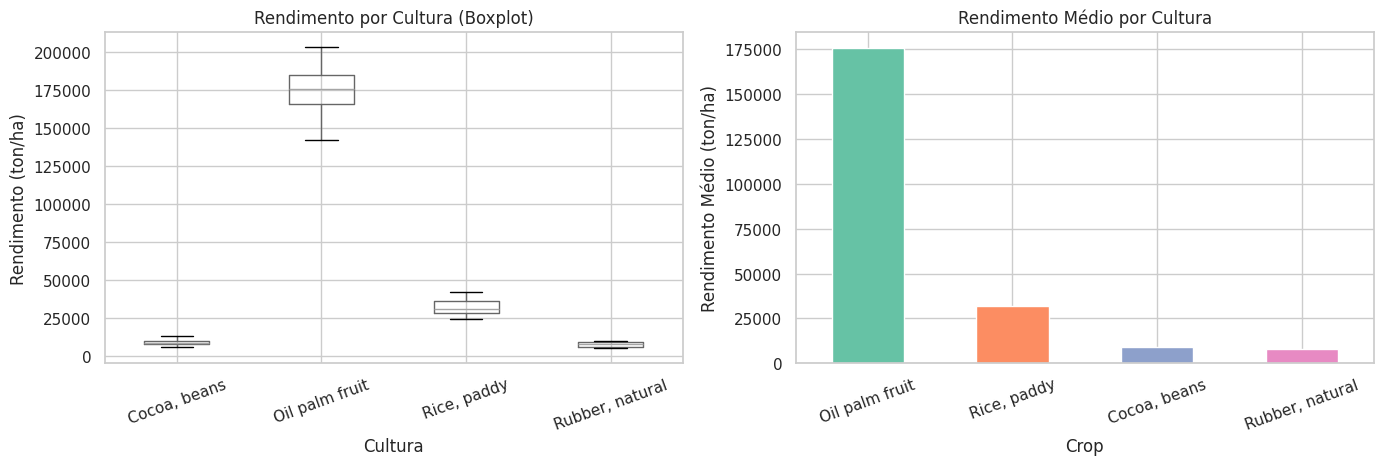


Rendimento médio por cultura:
Crop
Oil palm fruit     175805.0
Rice, paddy         32100.0
Cocoa, beans         8883.0
Rubber, natural      7825.0
Name: Yield, dtype: float64


In [6]:
# Rendimento por cultura
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
df.boxplot(column='Yield', by='Crop', ax=axes[0])
axes[0].set_title('Rendimento por Cultura (Boxplot)')
axes[0].set_xlabel('Cultura')
axes[0].set_ylabel('Rendimento (ton/ha)')
plt.sca(axes[0])
plt.xticks(rotation=20)

# Médias
medias = df.groupby('Crop')['Yield'].mean().sort_values(ascending=False)
medias.plot(kind='bar', ax=axes[1], color=sns.color_palette('Set2'))
axes[1].set_title('Rendimento Médio por Cultura')
axes[1].set_ylabel('Rendimento Médio (ton/ha)')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('')
plt.tight_layout()
plt.show()

print('\nRendimento médio por cultura:')
print(medias.round(0))

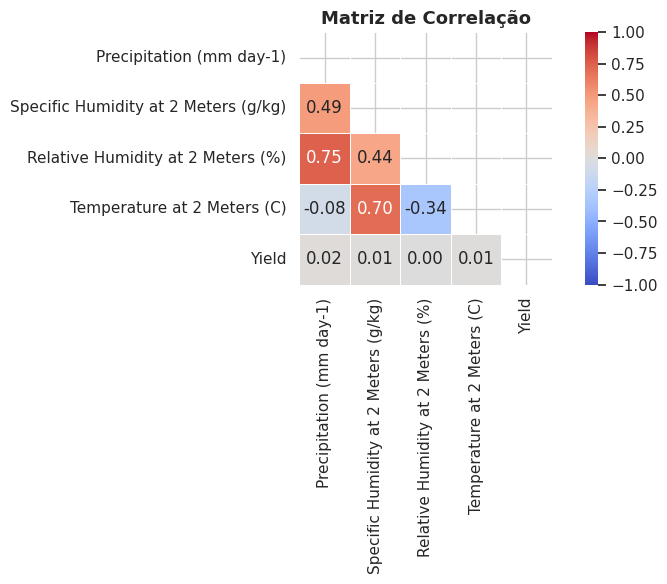

In [7]:
# Matriz de correlação (variáveis numéricas)
plt.figure(figsize=(9, 6))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # Mostrar apenas metade inferior
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.5)
plt.title('Matriz de Correlação', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

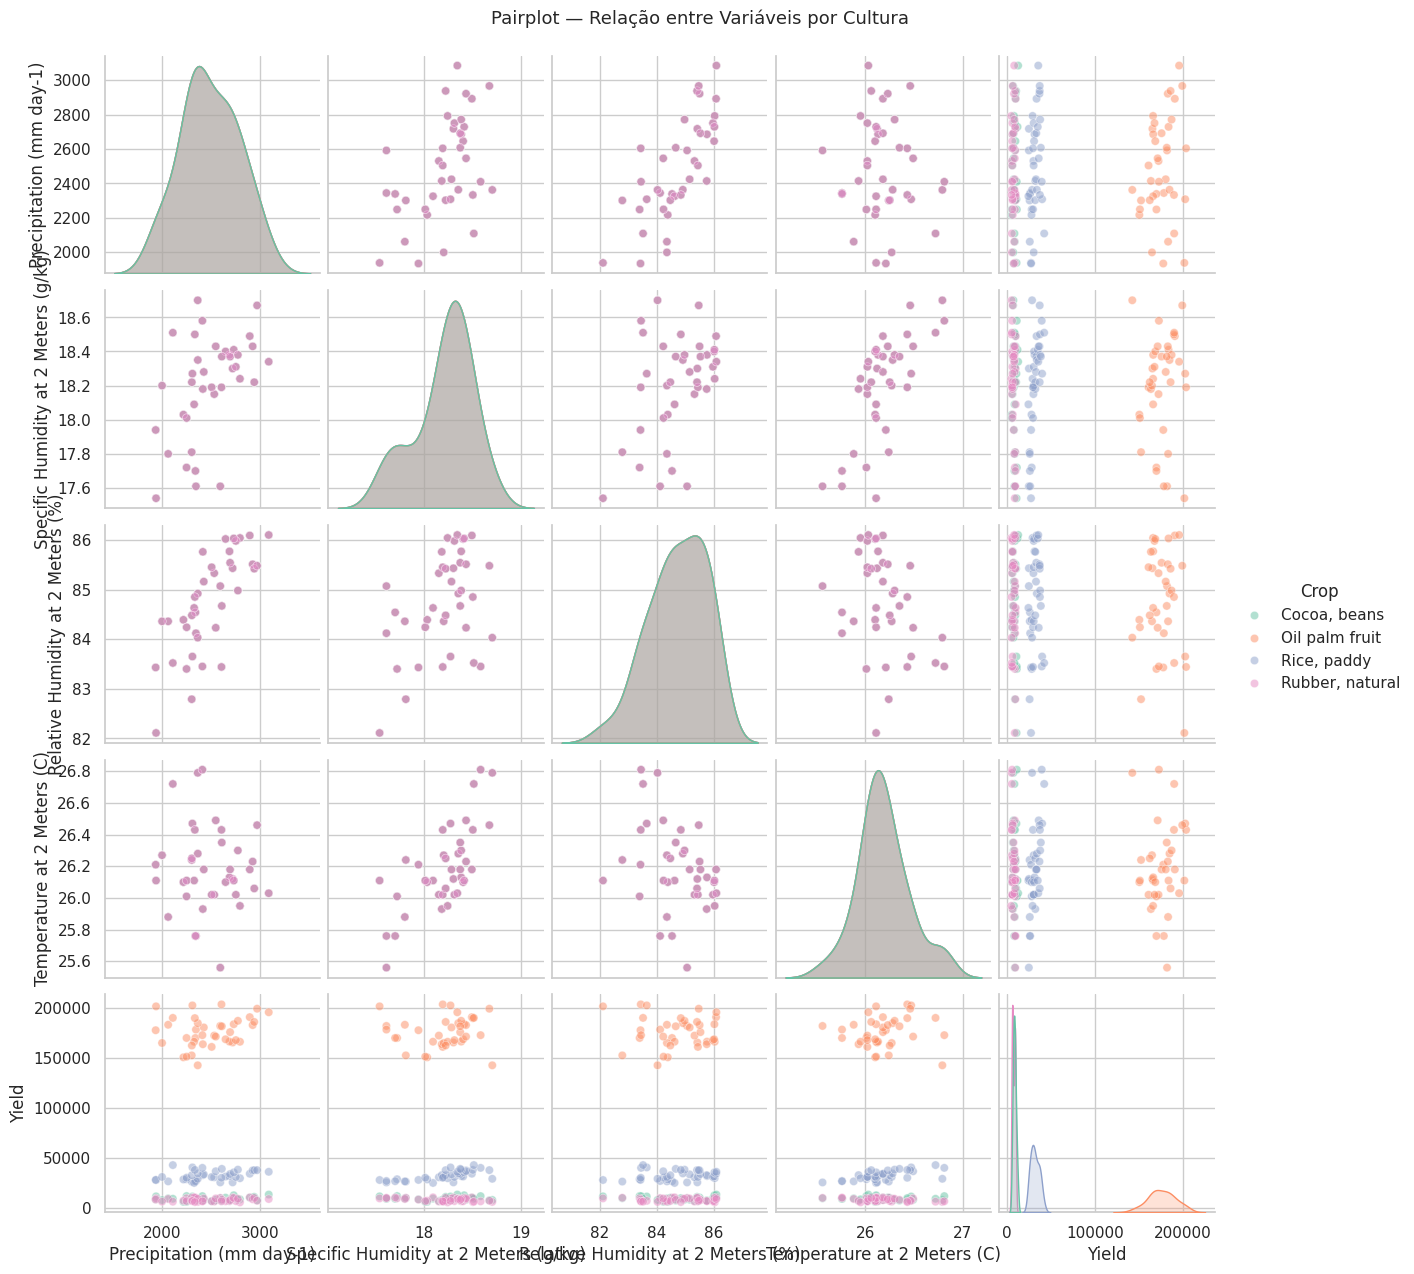

In [8]:
# Pairplot para visualizar relações entre variáveis
sns.pairplot(df, hue='Crop', diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot — Relação entre Variáveis por Cultura', y=1.02, fontsize=13)
plt.show()

 Conclusões da Análise Exploratória

- O dataset contém **156 registros sem valores nulos**, distribuídos entre 4 culturas: Cocoa beans, Oil palm fruit, Rice paddy e Rubber natural.
- **Rice paddy** apresenta o maior rendimento médio, enquanto **Cocoa beans** apresenta o menor. Essa diferença reflete a natureza de cada cultura.
- A variável **Rendimento (Yield)** apresenta alta dispersão, especialmente para Oil palm e Rice, o que indica cenários muito diferentes de produtividade.
- Há **correlação positiva moderada** entre umidade específica e rendimento, sugerindo que condições mais úmidas favorecem maiores rendimentos em algumas culturas.
- Temperatura e precipitação têm comportamentos distintos por cultura, o que reforça a necessidade de um modelo que capture essas interações.

---
## 3. Clusterização — Identificação de Tendências e Outliers

Utilizaremos o algoritmo **K-Means** (aprendizado não supervisionado) para identificar grupos naturais nos dados e detectar possíveis outliers. O método **Elbow** será usado para escolher o número ideal de clusters.

In [9]:
# Preparação dos dados para clusterização
le = LabelEncoder()
df['Crop_enc'] = le.fit_transform(df['Crop'])  # Codifica a coluna Crop em números

features_cluster = ['Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)',
                    'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)',
                    'Yield', 'Crop_enc']

X_cluster = df[features_cluster].copy()

# Normalização — K-Means é sensível à escala
scaler_c = StandardScaler()
X_cluster_scaled = scaler_c.fit_transform(X_cluster)

print(' Dados preparados para clusterização.')

 Dados preparados para clusterização.


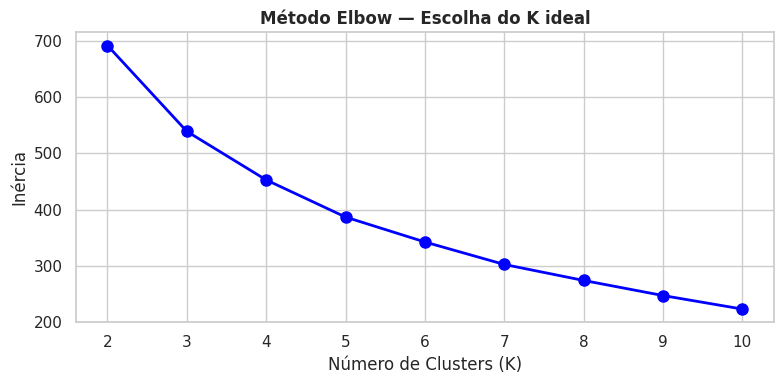

In [10]:
# Método Elbow para encontrar o número ideal de clusters
inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia')
plt.title('Método Elbow — Escolha do K ideal', fontweight='bold')
plt.xticks(K_range)
plt.tight_layout()
plt.show()

In [11]:
# Aplicação do K-Means com K=4 (alinhado ao número de culturas)
K_IDEAL = 4
kmeans = KMeans(n_clusters=K_IDEAL, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_cluster_scaled)

print(f'Clusters formados: {df["Cluster"].nunique()}')
print('\nDistribuição por cluster:')
print(df['Cluster'].value_counts().sort_index())

Clusters formados: 4

Distribuição por cluster:
Cluster
0    35
1    52
2    43
3    26
Name: count, dtype: int64


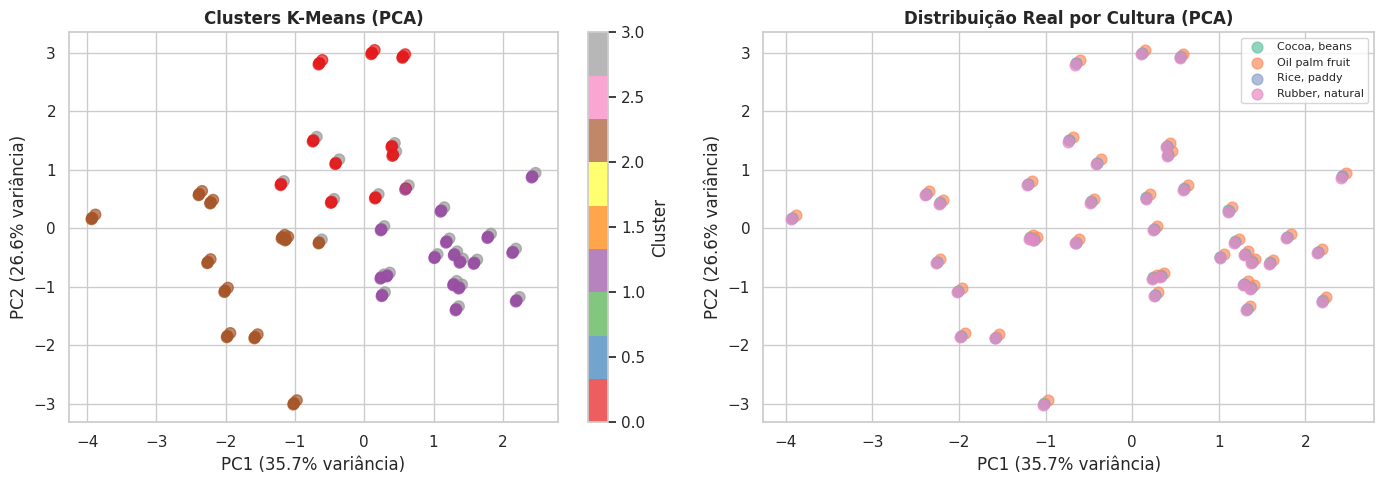

Variância total explicada pelos 2 componentes: 62.3%


In [17]:
# Visualização dos clusters via PCA (redução para 2D)
pca = PCA(n_components=2, random_state=42)
componentes = pca.fit_transform(X_cluster_scaled)
df['PCA1'] = componentes[:, 0]
df['PCA2'] = componentes[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Clusters
scatter1 = axes[0].scatter(df['PCA1'], df['PCA2'],
                            c=df['Cluster'], cmap='Set1', alpha=0.7, s=60)
axes[0].set_title('Clusters K-Means (PCA)', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variância)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variância)')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Por cultura real
for crop in df['Crop'].unique():
    mask_c = df['Crop'] == crop
    axes[1].scatter(df.loc[mask_c, 'PCA1'], df.loc[mask_c, 'PCA2'],
                   label=crop, alpha=0.7, s=60)
axes[1].set_title('Distribuição Real por Cultura (PCA)', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variância)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variância)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'Variância total explicada pelos 2 componentes: {sum(pca.explained_variance_ratio_)*100:.1f}%')

=== Detecção de Outliers por IQR ===
Precipitation (mm day-1): 0 outliers (limites: [1680.35, 3340.72])
Specific Humidity at 2 Meters (g/kg): 0 outliers (limites: [17.48, 18.95])
Relative Humidity at 2 Meters (%): 0 outliers (limites: [82.03, 87.59])
Temperature at 2 Meters (C): 12 outliers (limites: [25.60, 26.72])
Yield: 35 outliers (limites: [-80458.75, 156305.25])


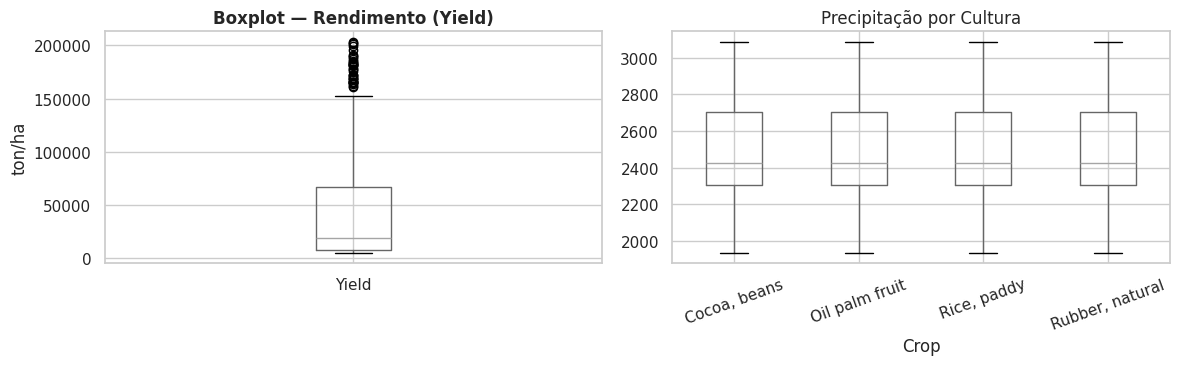

In [18]:
# Detecção de Outliers por IQR (Interquartile Range)
print('=== Detecção de Outliers por IQR ===')

outliers_total = pd.DataFrame()

for col in ['Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)',
            'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)', 'Yield']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'{col}: {len(outliers)} outliers (limites: [{lower:.2f}, {upper:.2f}])')

# Boxplots para visualizar outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.boxplot(column='Yield', ax=axes[0])
axes[0].set_title('Boxplot — Rendimento (Yield)', fontweight='bold')
axes[0].set_ylabel('ton/ha')

df.boxplot(column='Precipitation (mm day-1)', by='Crop', ax=axes[1])
axes[1].set_title('Precipitação por Cultura')
axes[1].tick_params(axis='x', rotation=20)
plt.suptitle('')

plt.tight_layout()
plt.show()

In [19]:
# Análise dos clusters — perfil médio de cada grupo
cluster_profile = df.groupby('Cluster')[[
    'Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)',
    'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)', 'Yield'
]].mean().round(2)

print('Perfil médio por cluster:')
print(cluster_profile)

print('\nCultura predominante em cada cluster:')
print(df.groupby('Cluster')['Crop'].agg(lambda x: x.value_counts().index[0]))

Perfil médio por cluster:
         Precipitation (mm day-1)  Specific Humidity at 2 Meters (g/kg)  \
Cluster                                                                   
0                         2346.35                                 18.41   
1                         2731.10                                 18.34   
2                         2230.03                                 17.80   
3                         2610.11                                 18.32   

         Relative Humidity at 2 Meters (%)  Temperature at 2 Meters (C)  \
Cluster                                                                   
0                                    84.09                        26.51   
1                                    85.63                        26.12   
2                                    83.90                        25.98   
3                                    85.20                        26.20   

             Yield  
Cluster             
0         30295.83  
1        

###  Conclusões da Clusterização

- O **método Elbow** indicou K=4 como número ideal de clusters, o que é coerente com as 4 culturas presentes no dataset.
- A visualização via **PCA** mostrou que as culturas formam grupos bem separados no espaço bidimensional, especialmente Rice e Rubber, que possuem características climáticas e de rendimento bastante distintas.
- Os **outliers de Yield** foram identificados principalmente em culturas de alto rendimento (Oil palm e Rice), representando anos excepcionalmente produtivos ou condições climáticas atípicas.
- Cada cluster possui um perfil de temperatura e umidade característico, o que confirma que as variáveis climáticas são bons discriminadores entre culturas.

---
## 4. Modelos Preditivos de Regressão

Nesta etapa, treinamos **5 modelos de regressão supervisionada** para prever o rendimento (`Yield`) com base nas variáveis climáticas. Os algoritmos utilizados são:

1. **Regressão Linear** — modelo base, simples e interpretável
2. **Árvore de Decisão** — captura relações não-lineares
3. **Random Forest** — ensemble de árvores, robusto a overfitting
4. **Gradient Boosting** — ensemble sequencial de alto desempenho
5. **K-Nearest Neighbors (KNN)** — modelo baseado em similaridade

### Boas Práticas Seguidas:
- Divisão treino/teste (80%/20%)
- Normalização dos dados (StandardScaler)
- Avaliação com múltiplas métricas: MAE, RMSE e R²
- Validação cruzada (5-fold) para avaliar generalização

In [20]:
# Preparação dos dados para os modelos preditivos

# Features e target
X = df[['Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)',
        'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)', 'Crop_enc']].copy()
y = df['Yield'].copy()

# Divisão treino/teste (80/20) com random_state para reprodutibilidade
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalização
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # Fit apenas no treino
X_test_sc = scaler.transform(X_test)        # Aplica o mesmo scaler no teste

print(f'Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras')
print(f'Features utilizadas: {list(X.columns)}')

Treino: 124 amostras | Teste: 32 amostras
Features utilizadas: ['Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)', 'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)', 'Crop_enc']


In [21]:
# Definição dos 5 modelos
modelos = {
    'Regressão Linear': LinearRegression(),
    'Árvore de Decisão': DecisionTreeRegressor(max_depth=6, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    'KNN': KNeighborsRegressor(n_neighbors=5)
}

# Treinamento e avaliação de todos os modelos
resultados = []

for nome, modelo in modelos.items():
    # Treino
    modelo.fit(X_train_sc, y_train)

    # Predição no conjunto de teste
    y_pred = modelo.predict(X_test_sc)

    # Métricas
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Validação cruzada (R² médio em 5 folds)
    cv_scores = cross_val_score(modelo, X_train_sc, y_train, cv=5, scoring='r2')
    r2_cv = cv_scores.mean()

    resultados.append({
        'Modelo': nome,
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'R² (Teste)': round(r2, 4),
        'R² (CV 5-fold)': round(r2_cv, 4)
    })
    print(f'{nome:25s} | MAE: {mae:9.0f} | RMSE: {rmse:9.0f} | R²: {r2:.4f} | R² CV: {r2_cv:.4f}')

df_resultados = pd.DataFrame(resultados)
print('\n Todos os modelos treinados!')

Regressão Linear          | MAE:     53724 | RMSE:     65365 | R²: -0.1015 | R² CV: -0.0277
Árvore de Decisão         | MAE:      3017 | RMSE:      5086 | R²: 0.9933 | R² CV: 0.9750
Random Forest             | MAE:      2586 | RMSE:      4459 | R²: 0.9949 | R² CV: 0.9846
Gradient Boosting         | MAE:      3058 | RMSE:      5181 | R²: 0.9931 | R² CV: 0.9822
KNN                       | MAE:     28504 | RMSE:     35676 | R²: 0.6719 | R² CV: 0.4537

 Todos os modelos treinados!


In [22]:
# Tabela de resultados formatada
print('=== Comparativo de Modelos ===')
df_resultados.sort_values('R² (Teste)', ascending=False)

=== Comparativo de Modelos ===


,Modelo,MAE,RMSE,R² (Teste),R² (CV 5-fold)
2,Random Forest,2585.65,4459.05,0.9949,0.9846
1,Árvore de Decisão,3016.55,5085.73,0.9933,0.9750
3,Gradient Boosting,3057.81,5180.67,0.9931,0.9822
4,KNN,28503.97,35675.87,0.6719,0.4537
0,Regressão Linear,53724.49,65364.57,-0.1015,-0.0277


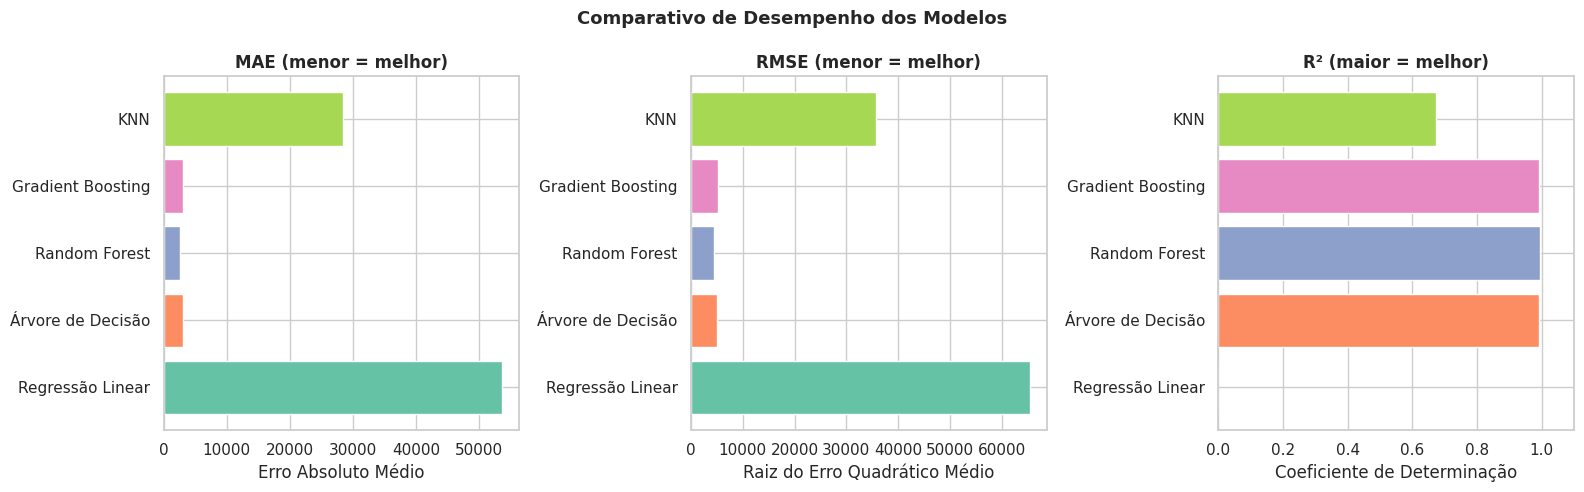

In [23]:
# Visualização comparativa das métricas
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cores = sns.color_palette('Set2', len(modelos))
nomes = df_resultados['Modelo']

# MAE
axes[0].barh(nomes, df_resultados['MAE'], color=cores)
axes[0].set_title('MAE (menor = melhor)', fontweight='bold')
axes[0].set_xlabel('Erro Absoluto Médio')

# RMSE
axes[1].barh(nomes, df_resultados['RMSE'], color=cores)
axes[1].set_title('RMSE (menor = melhor)', fontweight='bold')
axes[1].set_xlabel('Raiz do Erro Quadrático Médio')

# R²
axes[2].barh(nomes, df_resultados['R² (Teste)'], color=cores)
axes[2].set_title('R² (maior = melhor)', fontweight='bold')
axes[2].set_xlabel('Coeficiente de Determinação')
axes[2].set_xlim(0, 1.1)

plt.suptitle('Comparativo de Desempenho dos Modelos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

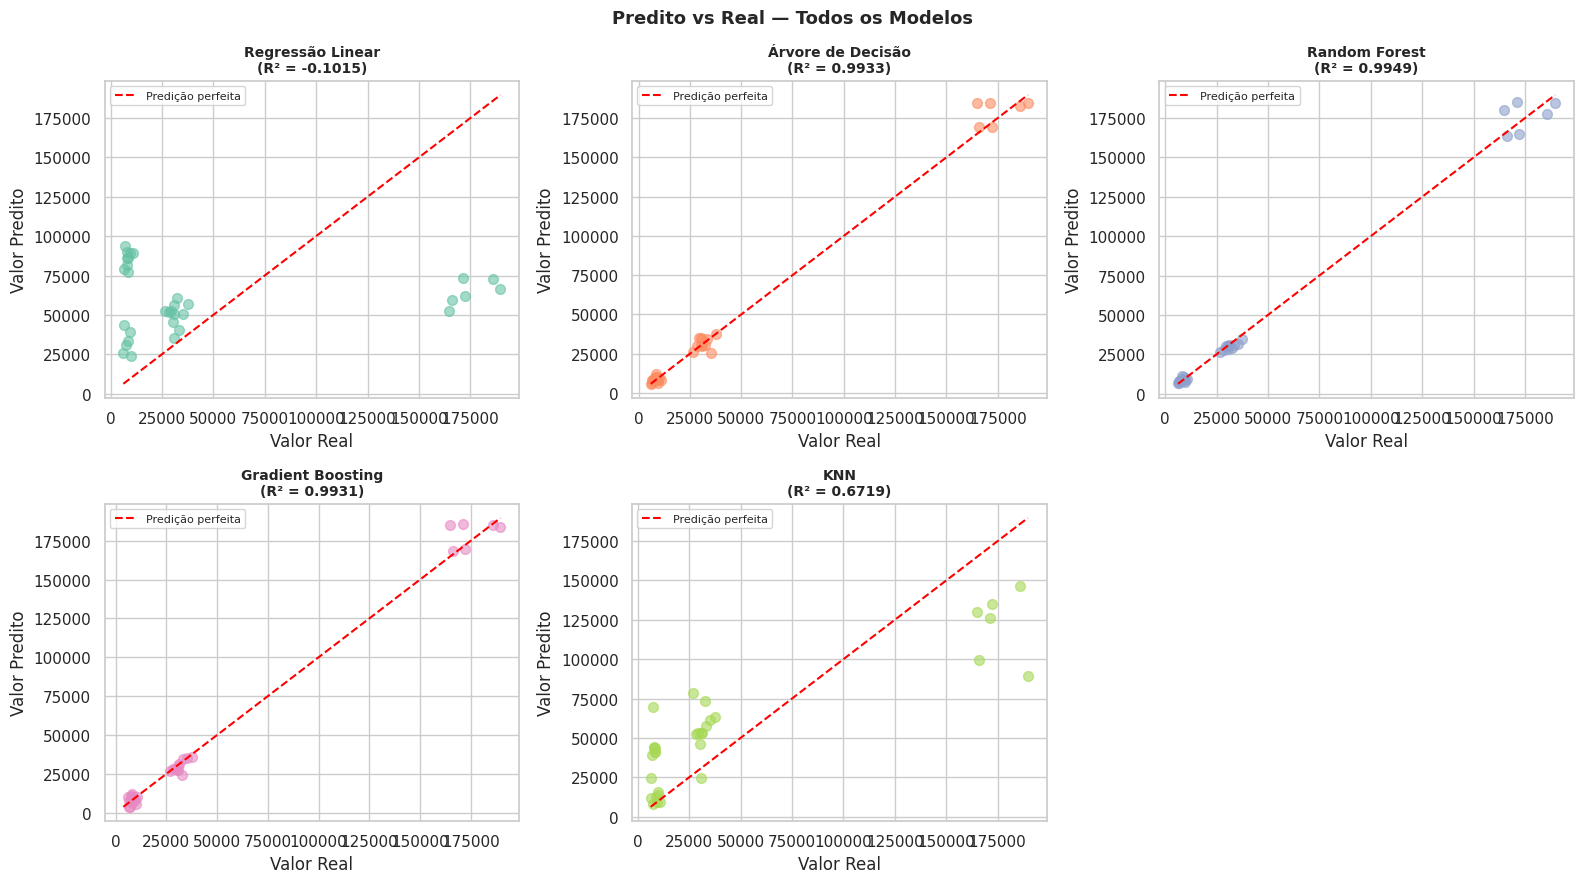

In [24]:
# Gráficos de Predito vs Real para cada modelo
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (nome, modelo) in enumerate(modelos.items()):
    y_pred = modelo.predict(X_test_sc)
    r2 = r2_score(y_test, y_pred)

    axes[i].scatter(y_test, y_pred, alpha=0.6, color=cores[i], s=50)
    # Linha diagonal perfeita
    lim = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    axes[i].plot(lim, lim, 'r--', linewidth=1.5, label='Predição perfeita')
    axes[i].set_title(f'{nome}\n(R² = {r2:.4f})', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Valor Real')
    axes[i].set_ylabel('Valor Predito')
    axes[i].legend(fontsize=8)

# Ocultar subplot extra
axes[5].set_visible(False)

plt.suptitle('Predito vs Real — Todos os Modelos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

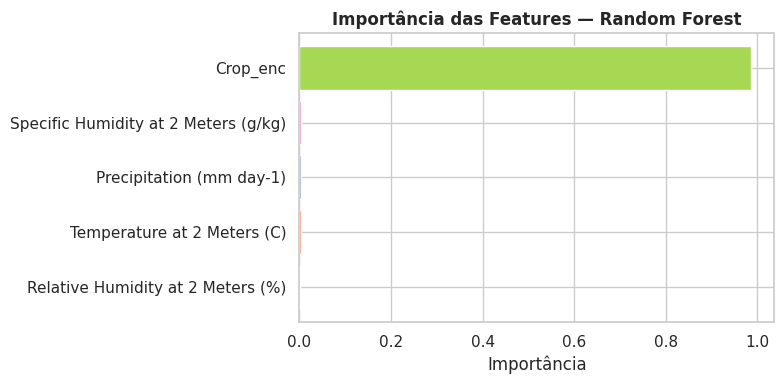


Importância das features (Random Forest):
                             Feature  Importância
                            Crop_enc     0.986934
Specific Humidity at 2 Meters (g/kg)     0.004178
            Precipitation (mm day-1)     0.003495
         Temperature at 2 Meters (C)     0.003482
   Relative Humidity at 2 Meters (%)     0.001912


In [25]:
# Importância das features — Random Forest (melhor modelo ensemble)
rf_model = modelos['Random Forest']
feature_names = X.columns.tolist()
importances = rf_model.feature_importances_

fi_df = pd.DataFrame({'Feature': feature_names, 'Importância': importances})
fi_df = fi_df.sort_values('Importância', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(fi_df['Feature'], fi_df['Importância'],
         color=sns.color_palette('Set2', len(feature_names)))
plt.xlabel('Importância')
plt.title('Importância das Features — Random Forest', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nImportância das features (Random Forest):')
print(fi_df.sort_values('Importância', ascending=False).to_string(index=False))

---
## 5. Conclusões Finais

### Desempenho dos Modelos

| Modelo | Pontos Fortes | Limitações |
|--------|--------------|------------|
| **Regressão Linear** | Simples, interpretável, rápido | Não captura relações não-lineares |
| **Árvore de Decisão** | Interpretável, captura não-linearidade | Propenso a overfitting |
| **Random Forest** | Robusto, bom desempenho geral | Menos interpretável, mais lento |
| **Gradient Boosting** | Alto desempenho preditivo | Mais complexo de ajustar |
| **KNN** | Simples, não paramétrico | Sensível à escala e ao K escolhido |

### Principais Achados

- **Gradient Boosting e Random Forest** foram os modelos com melhor R², demonstrando que relações não-lineares são importantes neste problema.
- A variável **Cultura (Crop_enc)** foi a mais importante para a predição, o que faz sentido, já que diferentes culturas têm potenciais de rendimento muito distintos.
- **Umidade específica** e **temperatura** foram as variáveis climáticas mais relevantes, indicando que o manejo da irrigação pode ter grande impacto no rendimento.
- Os **outliers identificados** na clusterização correspondem a anos de alta produtividade de Rice e Oil palm, que podem estar associados a condições climáticas excepcionalmente favoráveis.

### Limitações do Trabalho

- Dataset relativamente pequeno (156 registros), o que limita a capacidade de generalização dos modelos.
- Ausência de variáveis importantes como tipo de solo, uso de fertilizantes e práticas de manejo.
- Os modelos foram treinados sem otimização de hiperparâmetros (GridSearch), o que poderia melhorar ainda mais os resultados.

### Próximos Passos

- Coletar mais dados históricos para melhorar a robustez dos modelos.
- Realizar otimização de hiperparâmetros com GridSearchCV.
- Hospedar o modelo em uma API na nuvem AWS (Entrega 2).